# Analisi DRL sulla viralità della disinformazione

Questo notebook analizza un file di log generato da una simulazione DRL.

Nel log sono presenti:
- parametri iniziali della simulazione
- righe `ENV_STEP` con `tick`, `virality`, `reward`
- righe `SA_ACTION` con l'azione scelta dal sistema (`go`, `reiterate`, ecc.)

## Obiettivi
1. Ricostruire gli episodi dal log
2. Analizzare l'andamento della viralità
3. Analizzare reward e performance per episodio
4. Studiare le azioni selezionate dal modello
5. Mettere in relazione azioni, virality e reward

> Il notebook assume come input il file `log_2026-04-20_20-31-27.txt` nella stessa cartella del notebook.

In [18]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

LOG_PATH = Path("test_general_sa_1_result/log_2026-04-20_23-50-11.txt")
assert LOG_PATH.exists(), f"File non trovato: {LOG_PATH.resolve()}"

print("Log trovato:", LOG_PATH.resolve())

Log trovato: /Users/luigilomasto/Documents/GitHub/RADAR-AS/test_general_sa_1_result/log_2026-04-20_23-50-11.txt


## 1. Parsing del file di log

In [19]:
ENV_PATTERN = re.compile(
    r"\[ENV_STEP\]\s+tick=(?P<tick>[\d.]+)\s+virality=(?P<virality>[\d.]+)\s+reward=(?P<reward>[-\d.]+)"
)

ACTION_PATTERN = re.compile(
    r"\[SA_ACTION\]\s+tick=(?P<tick>\d+)\s+action=(?P<action_id>\d+)\s+\((?P<action_name>[^)]+)\)\s+virality=(?P<virality>[\d.]+)\s+reward=(?P<reward>[-\d.]+)"
)

CONFIG_PATTERN = re.compile(r"^(?P<key>[^:\n]+):\s*(?P<value>.+)$")


def parse_log_file(log_path: Path):
    text = log_path.read_text(encoding="utf-8", errors="ignore")
    lines = text.splitlines()

    config = {}
    env_rows = []
    action_rows = []

    current_episode = 0
    prev_env_tick = None
    current_action_episode = 0
    prev_action_tick = None

    for line in lines:
        line = line.strip()

        m_cfg = CONFIG_PATTERN.match(line)
        if m_cfg and not line.startswith("["):
            config[m_cfg.group("key").strip()] = m_cfg.group("value").strip()

        m_env = ENV_PATTERN.search(line)
        if m_env:
            tick = int(float(m_env.group("tick")))
            virality = float(m_env.group("virality"))
            reward = float(m_env.group("reward"))

            if prev_env_tick is not None and tick <= prev_env_tick:
                current_episode += 1

            env_rows.append({
                "episode": current_episode,
                "tick": tick,
                "virality": virality,
                "reward": reward,
            })

            prev_env_tick = tick
            continue

        m_act = ACTION_PATTERN.search(line)
        if m_act:
            tick = int(m_act.group("tick"))
            if prev_action_tick is not None and tick <= prev_action_tick:
                current_action_episode += 1

            action_rows.append({
                "episode": current_action_episode,
                "tick": tick,
                "action_id": int(m_act.group("action_id")),
                "action_name": m_act.group("action_name").strip(),
                "virality_at_action": float(m_act.group("virality")),
                "reward_at_action": float(m_act.group("reward")),
            })

            prev_action_tick = tick

    env_df = pd.DataFrame(env_rows)
    action_df = pd.DataFrame(action_rows)

    if env_df.empty:
        raise ValueError("Nessuna riga ENV_STEP trovata nel log.")

    return config, env_df, action_df


config, env_df, action_df = parse_log_file(LOG_PATH)

print("Numero episodi trovati:", env_df["episode"].nunique())
print("Numero ENV_STEP:", len(env_df))
print("Numero SA_ACTION:", len(action_df))

Numero episodi trovati: 200
Numero ENV_STEP: 20000
Numero SA_ACTION: 4900


## 2. Configurazione iniziale

In [20]:
config_df = pd.DataFrame(
    [{"parametro": k, "valore": v} for k, v in config.items()]
)
config_df

,parametro,valore
0,Numero di Ticks,100
1,Numero di Iterazioni,100
2,Opinion Polarization,0.0
3,Network Polarization,[0.15]
4,Thresholds Polarization,[0.15]
5,warning,True
6,node_range_static_b,0.05
7,node_range,0.1
8,choose_method,degree
9,warning_impact,0.1


## 3. Anteprima dei dati

In [21]:
display(env_df.head(10))
display(action_df.head(10))

,episode,tick,virality,reward
0,0,1,0.21,0.0000
1,0,2,0.19,1.1544
2,0,3,0.33,0.5814
3,0,4,0.39,1.0000
4,0,5,0.52,0.6009
5,0,6,0.58,0.5241
6,0,7,0.64,0.4501
7,0,8,0.66,0.0000
8,0,9,0.69,0.0000
9,0,10,0.73,0.4622


,episode,tick,action_id,action_name,virality_at_action,reward_at_action
0,0,3,1,warning,0.52,0.3763
1,0,5,0,go,0.69,0.0000
2,0,7,0,go,0.91,0.0000
3,0,9,0,go,0.94,0.0000
4,0,11,0,go,0.97,0.0000
5,0,13,0,go,0.98,1.0000
6,0,15,0,go,1.00,1.0000
7,0,17,0,go,1.00,1.0000
8,0,19,0,go,1.00,1.0000
9,0,21,0,go,1.00,1.0000


## 4. Statistiche per episodio

In [22]:
episode_summary = (
    env_df.groupby("episode")
    .agg(
        ticks=("tick", "max"),
        initial_virality=("virality", "first"),
        final_virality=("virality", "last"),
        mean_virality=("virality", "mean"),
        max_virality=("virality", "max"),
        total_reward=("reward", "sum"),
        mean_reward=("reward", "mean"),
    )
    .reset_index()
)

if not action_df.empty:
    action_counts = (
        action_df.groupby(["episode", "action_name"])
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )
    episode_summary = episode_summary.merge(action_counts, on="episode", how="left").fillna(0)
    episode_summary["n_actions"] = action_df.groupby("episode").size().reindex(episode_summary["episode"]).fillna(0).values
else:
    episode_summary["n_actions"] = 0

episode_summary.head()

,episode,ticks,initial_virality,final_virality,mean_virality,max_virality,total_reward,mean_reward,go,reiterate,static_b,warning,n_actions
0,0,100,0.21,0.95,0.8947,0.95,36.6846,0.366846,48.0,0.0,0.0,1.0,49.0
1,1,100,0.13,0.95,0.8567,0.95,30.9396,0.309396,48.0,0.0,0.0,1.0,49.0
2,2,100,0.12,0.00,0.0086,0.14,113.3198,1.133198,0.0,47.0,1.0,1.0,49.0
3,3,100,0.14,0.00,0.0267,0.33,108.3096,1.083096,48.0,0.0,0.0,1.0,49.0
4,4,100,0.11,0.00,0.0104,0.19,110.7061,1.107061,48.0,0.0,0.0,1.0,49.0


In [23]:
summary_stats = pd.Series({
    "episodi": env_df["episode"].nunique(),
    "ticks totali": len(env_df),
    "azioni totali": len(action_df),
    "virality finale media": episode_summary["final_virality"].mean(),
    "virality finale mediana": episode_summary["final_virality"].median(),
    "reward totale medio": episode_summary["total_reward"].mean(),
    "episodi con virality finale = 0": int((episode_summary["final_virality"] == 0).sum()),
})
summary_stats

episodi                              200.000000
ticks totali                       20000.000000
azioni totali                       4900.000000
virality finale media                  0.603650
virality finale mediana                0.950000
reward totale medio                   93.269882
episodi con virality finale = 0       76.000000
dtype: float64

## 5. Andamento medio della virality nel tempo

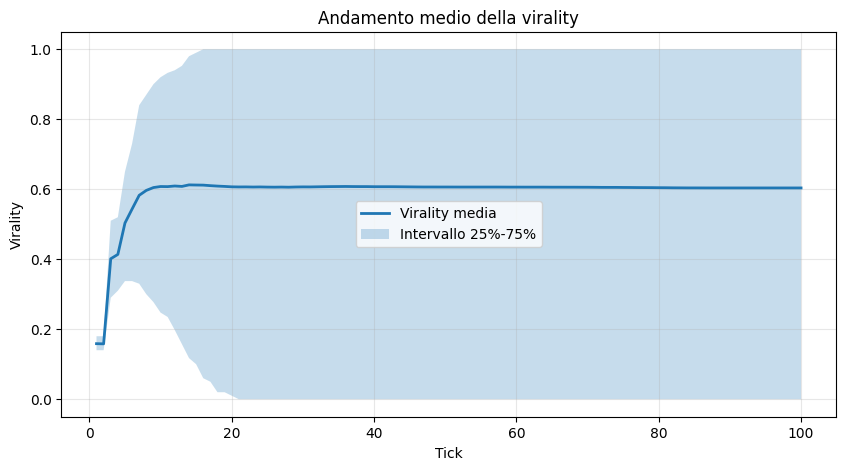

In [24]:
virality_curve = (
    env_df.groupby("tick")
    .agg(
        mean_virality=("virality", "mean"),
        q25=("virality", lambda x: np.quantile(x, 0.25)),
        q75=("virality", lambda x: np.quantile(x, 0.75)),
    )
    .reset_index()
)

plt.figure()
plt.plot(virality_curve["tick"], virality_curve["mean_virality"], linewidth=2, label="Virality media")
plt.fill_between(
    virality_curve["tick"],
    virality_curve["q25"],
    virality_curve["q75"],
    alpha=0.25,
    label="Intervallo 25%-75%"
)
plt.xlabel("Tick")
plt.ylabel("Virality")
plt.title("Andamento medio della virality")
plt.legend()
plt.show()

## 6. Reward medio nel tempo

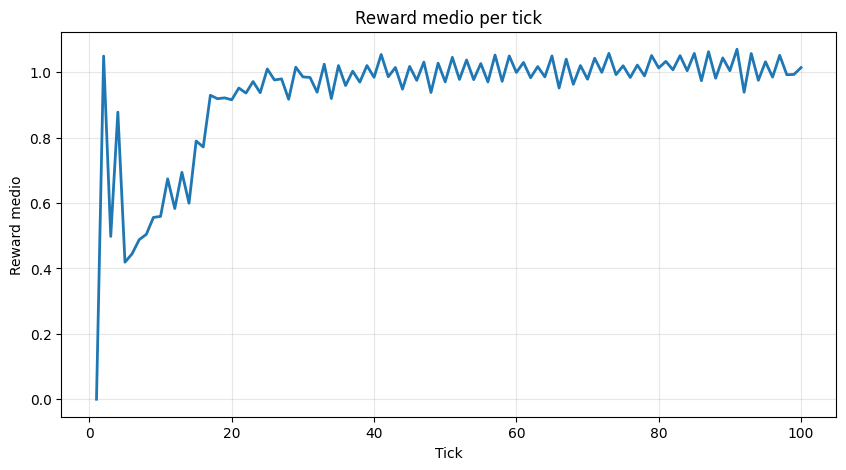

In [25]:
reward_curve = env_df.groupby("tick")["reward"].mean().reset_index()

plt.figure()
plt.plot(reward_curve["tick"], reward_curve["reward"], linewidth=2)
plt.xlabel("Tick")
plt.ylabel("Reward medio")
plt.title("Reward medio per tick")
plt.show()

## 7. Distribuzione della virality finale e del reward totale

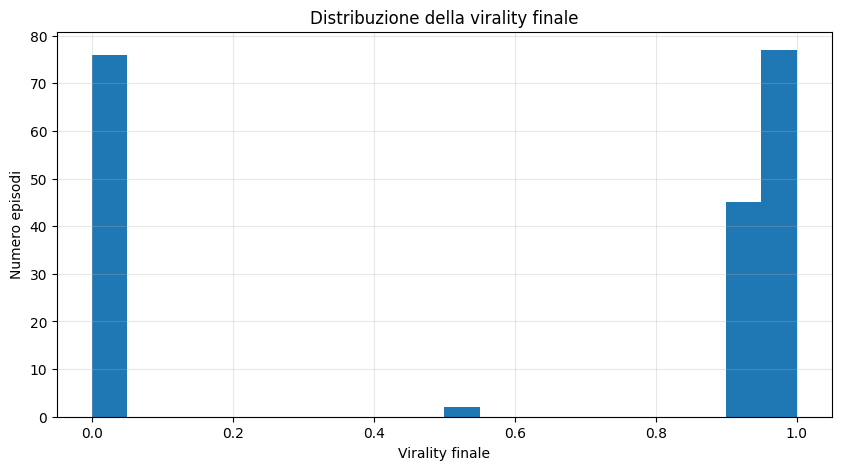

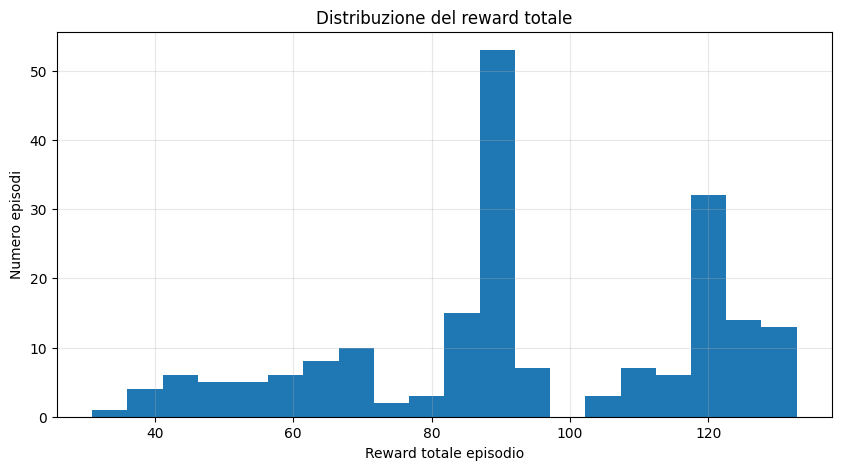

In [26]:
plt.figure()
plt.hist(episode_summary["final_virality"], bins=20)
plt.xlabel("Virality finale")
plt.ylabel("Numero episodi")
plt.title("Distribuzione della virality finale")
plt.show()

plt.figure()
plt.hist(episode_summary["total_reward"], bins=20)
plt.xlabel("Reward totale episodio")
plt.ylabel("Numero episodi")
plt.title("Distribuzione del reward totale")
plt.show()

## 8. Migliori e peggiori episodi

In [27]:
best_episodes = episode_summary.sort_values(["final_virality", "total_reward"], ascending=[True, False]).head(10)
worst_episodes = episode_summary.sort_values(["final_virality", "total_reward"], ascending=[False, False]).head(10)

print("Migliori 10 episodi:")
display(best_episodes)

print("Peggiori 10 episodi:")
display(worst_episodes)

Migliori 10 episodi:


,episode,ticks,initial_virality,final_virality,mean_virality,max_virality,total_reward,mean_reward,go,reiterate,static_b,warning,n_actions
97,97,100,0.17,0.0,0.0409,0.37,132.7565,1.327565,48.0,0.0,0.0,1.0,49.0
96,96,100,0.09,0.0,0.0085,0.14,131.5311,1.315311,48.0,0.0,0.0,1.0,49.0
98,98,100,0.15,0.0,0.0265,0.28,130.9088,1.309088,0.0,48.0,0.0,1.0,49.0
60,60,100,0.11,0.0,0.0346,0.33,130.9038,1.309038,48.0,0.0,0.0,1.0,49.0
80,80,100,0.13,0.0,0.0169,0.20,130.8822,1.308822,48.0,0.0,0.0,1.0,49.0
92,92,100,0.14,0.0,0.0376,0.34,130.3647,1.303647,48.0,0.0,0.0,1.0,49.0
77,77,100,0.16,0.0,0.0181,0.26,129.9630,1.299630,48.0,0.0,0.0,1.0,49.0
91,91,100,0.10,0.0,0.0118,0.17,129.5223,1.295223,0.0,48.0,0.0,1.0,49.0
81,81,100,0.14,0.0,0.0238,0.28,129.3513,1.293513,47.0,1.0,0.0,1.0,49.0
58,58,100,0.13,0.0,0.0196,0.25,129.0420,1.290420,48.0,0.0,0.0,1.0,49.0


Peggiori 10 episodi:


,episode,ticks,initial_virality,final_virality,mean_virality,max_virality,total_reward,mean_reward,go,reiterate,static_b,warning,n_actions
143,143,100,0.15,1.0,0.9698,1.0,93.2926,0.932926,0.0,0.0,0.0,0.0,0.0
120,120,100,0.18,1.0,0.9687,1.0,92.8801,0.928801,0.0,0.0,0.0,0.0,0.0
171,171,100,0.15,1.0,0.9658,1.0,92.4130,0.924130,0.0,0.0,0.0,0.0,0.0
124,124,100,0.17,1.0,0.9674,1.0,92.2530,0.922530,0.0,0.0,0.0,0.0,0.0
192,192,100,0.18,1.0,0.9678,1.0,92.2529,0.922529,0.0,0.0,0.0,0.0,0.0
150,150,100,0.28,1.0,0.9788,1.0,92.1114,0.921114,0.0,0.0,0.0,0.0,0.0
161,161,100,0.15,1.0,0.9664,1.0,91.5537,0.915537,0.0,0.0,0.0,0.0,0.0
180,180,100,0.17,1.0,0.9674,1.0,91.4065,0.914065,0.0,0.0,0.0,0.0,0.0
134,134,100,0.20,1.0,0.9713,1.0,91.3397,0.913397,0.0,0.0,0.0,0.0,0.0
163,163,100,0.23,1.0,0.9719,1.0,91.3371,0.913371,0.0,0.0,0.0,0.0,0.0


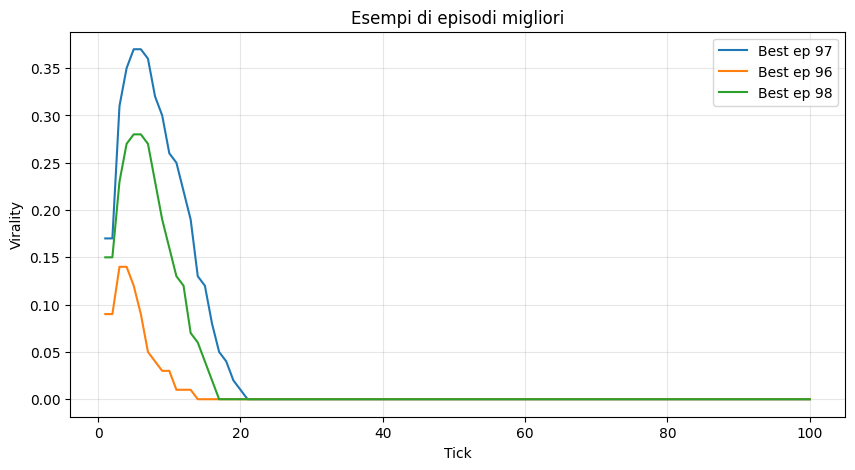

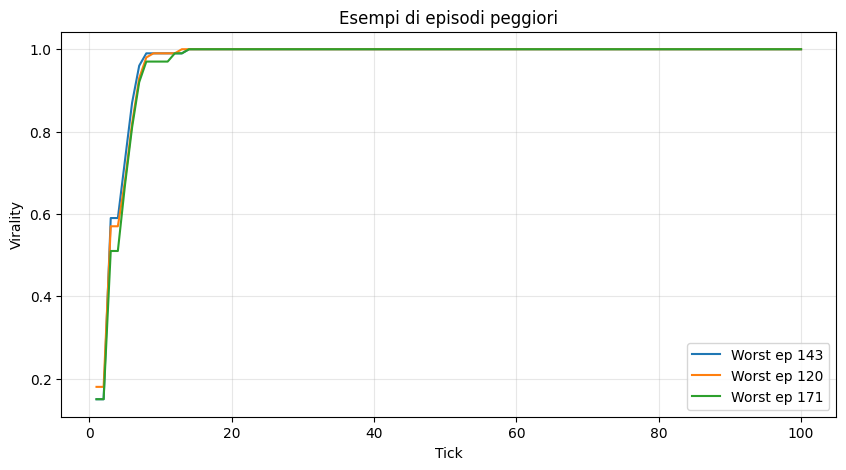

In [28]:
best_ids = best_episodes["episode"].head(3).tolist()
worst_ids = worst_episodes["episode"].head(3).tolist()

plt.figure()
for ep in best_ids:
    data = env_df[env_df["episode"] == ep]
    plt.plot(data["tick"], data["virality"], label=f"Best ep {ep}")
plt.xlabel("Tick")
plt.ylabel("Virality")
plt.title("Esempi di episodi migliori")
plt.legend()
plt.show()

plt.figure()
for ep in worst_ids:
    data = env_df[env_df["episode"] == ep]
    plt.plot(data["tick"], data["virality"], label=f"Worst ep {ep}")
plt.xlabel("Tick")
plt.ylabel("Virality")
plt.title("Esempi di episodi peggiori")
plt.legend()
plt.show()

## 9. Analisi delle azioni del modello

,action_name,count,percentage
0,go,3712,75.755102
1,reiterate,1084,22.122449
2,warning,101,2.061224
3,static_b,3,0.061224


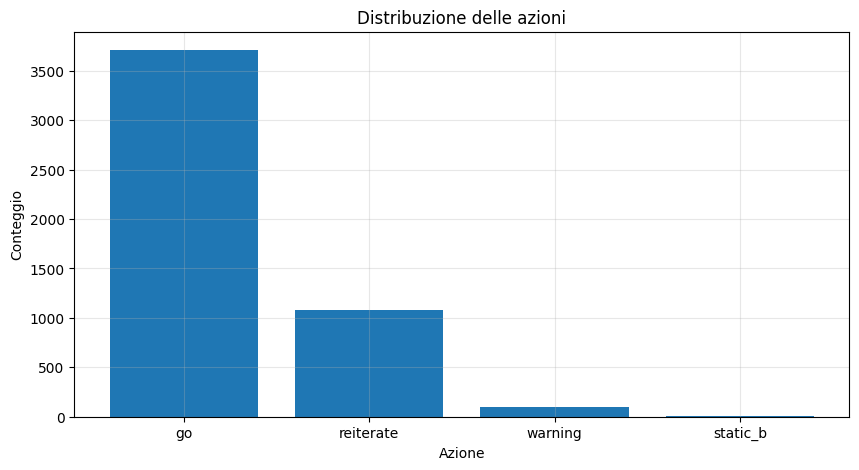

In [29]:
if action_df.empty:
    print("Nessuna SA_ACTION trovata nel log.")
else:
    action_distribution = (
        action_df["action_name"]
        .value_counts()
        .rename_axis("action_name")
        .reset_index(name="count")
    )
    action_distribution["percentage"] = 100 * action_distribution["count"] / action_distribution["count"].sum()
    display(action_distribution)

    plt.figure()
    plt.bar(action_distribution["action_name"], action_distribution["count"])
    plt.xlabel("Azione")
    plt.ylabel("Conteggio")
    plt.title("Distribuzione delle azioni")
    plt.show()

action_name,go,reiterate,static_b,warning
virality_band,,,,
0-0.1,0.00,100.00,0.00,0.00
0.1-0.3,0.00,83.91,1.15,14.94
0.3-0.6,31.78,30.37,0.93,36.92
0.6-0.8,83.33,10.32,0.00,6.35
0.8-1.0,99.97,0.00,0.00,0.03


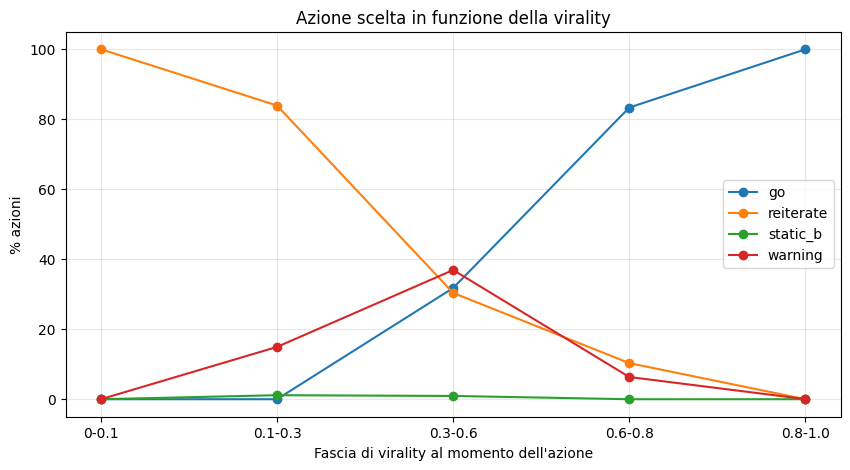

In [30]:
if not action_df.empty:
    bins = [0.0, 0.1, 0.3, 0.6, 0.8, 1.0]
    labels = ["0-0.1", "0.1-0.3", "0.3-0.6", "0.6-0.8", "0.8-1.0"]

    action_analysis = action_df.copy()
    action_analysis["virality_band"] = pd.cut(
        action_analysis["virality_at_action"],
        bins=bins,
        labels=labels,
        include_lowest=True
    )

    pivot = pd.crosstab(action_analysis["virality_band"], action_analysis["action_name"], normalize="index") * 100
    display(pivot.round(2))

    plt.figure()
    for col in pivot.columns:
        plt.plot(pivot.index.astype(str), pivot[col], marker="o", label=col)
    plt.xlabel("Fascia di virality al momento dell'azione")
    plt.ylabel("% azioni")
    plt.title("Azione scelta in funzione della virality")
    plt.legend()
    plt.show()

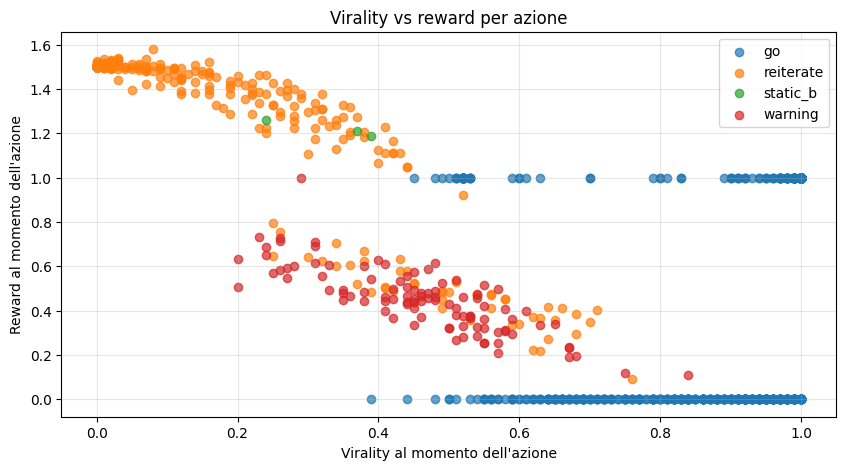

In [31]:
if not action_df.empty:
    plt.figure()
    for action_name, data in action_df.groupby("action_name"):
        plt.scatter(
            data["virality_at_action"],
            data["reward_at_action"],
            label=action_name,
            alpha=0.7
        )
    plt.xlabel("Virality al momento dell'azione")
    plt.ylabel("Reward al momento dell'azione")
    plt.title("Virality vs reward per azione")
    plt.legend()
    plt.show()

## 10. Relazione tra reward totale e virality finale

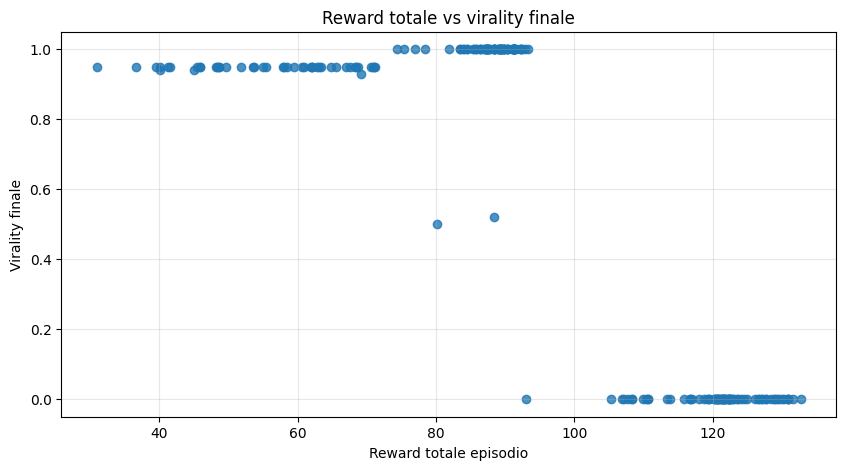

In [32]:
plt.figure()
plt.scatter(episode_summary["total_reward"], episode_summary["final_virality"], alpha=0.8)
plt.xlabel("Reward totale episodio")
plt.ylabel("Virality finale")
plt.title("Reward totale vs virality finale")
plt.show()

## 11. Esportazione facoltativa dei risultati

Questa cella salva i dataframe principali in CSV, utile per analisi successive o per inserire i risultati in una tesi/report.

In [33]:
OUTPUT_DIR = Path("output_analisi_drl")
OUTPUT_DIR.mkdir(exist_ok=True)

env_df.to_csv(OUTPUT_DIR / "env_steps.csv", index=False)
action_df.to_csv(OUTPUT_DIR / "actions.csv", index=False)
episode_summary.to_csv(OUTPUT_DIR / "episode_summary.csv", index=False)

print("File salvati in:", OUTPUT_DIR.resolve())

File salvati in: /Users/luigilomasto/Documents/GitHub/RADAR-AS/output_analisi_drl


## 12. Interpretazione suggerita

Quando leggi i risultati, guarda soprattutto:

- **virality finale media**: più è bassa, meglio il modello contiene la disinformazione
- **numero di episodi con virality finale = 0**: indica quante volte la diffusione è stata completamente azzerata
- **distribuzione delle azioni**: mostra se il policy DRL tende a preferire sempre la stessa azione
- **azioni per fascia di virality**: utile per capire se il modello cambia strategia quando la situazione peggiora
- **reward totale vs virality finale**: utile per verificare se la funzione di reward è davvero coerente con l'obiettivo di ridurre la viralità

Se vuoi, il passo successivo naturale è aggiungere una sezione finale che separi in modo esplicito:
1. **100 simulazioni di training**
2. **100 simulazioni di test/policy evaluation**

ma questo richiede che il log distingua chiaramente le due fasi oppure che i file siano separati.